In [3]:
import numpy as np
from matplotlib.pyplot import*
from scipy import stats as st
from scipy import optimize as op
from scipy import fftpack
from scipy import signal
from scipy.special import erf
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection
from scipy.integrate import *
%matplotlib inline  

In [5]:
Nx=30;Ny=30
deltax=1./Nx;deltay=1./Ny
deltat=.05*(deltay**2)

d=.2 # durée de l'évolution
Nt=int(d/deltat) # nombre de pas de temps


xx=np.linspace(0,1,Nx+1)
yy=np.linspace(0,1,Ny+1)
y,x=np.meshgrid(yy,xx)
theta=np.zeros((Nx+1,Ny+1)) 


#parametres géométriques du substrat
x1=.2
y1=.4

x2=.8
y2=.8

r=.1

#inclusion=np.bitwise_or((x-x1)**2+(y-y1)**2<=r**2,(x-x2)**2+(y-y2)**2<=r**2)


#disque
inclusion=(x-x1)**2+(y-y1)**2<=r**2 

#bande
inclusion=np.bitwise_and(y<=y1,y>=x1)
#inclusion=np.bitwise_and(np.bitwise_and(y<=y1,y>=-y1),x<=x1)
#cuivre=np.bitwise_and(np.bitwise_and(y<=y1,y>=-y1),x>x1)
#alumine=y<=-y1
#primer=y>=y1

#matrices de conductivité, masses volumiqes et capacité thermiques massiques
kappa=x*0+1
mu=x*0+1
c=x*0+1

 # on initialise la production à 0

#caractéristiques du milieu par rapport à la résistance

kappa[inclusion]=1e-1
mu[inclusion]=2.
c[inclusion]=2.


muc=mu*c


    




#inclusion

<ipython-input-60-bf712bdaab90>:5: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcolormesh(xx,yy,kappa, vmin=0, vmax=2.0)


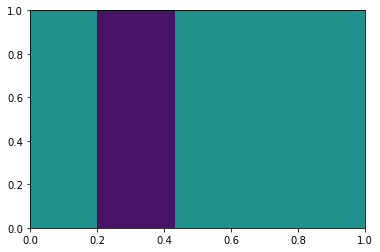

In [60]:
#imshow(theta,interpolation='none',cmap='coolwarm')#,vmin=0, vmax=.1,aspect='auto')
#imshow(production,interpolation='bilinear',cmap='gray',alpha=0.1)#,vmin=np.min(theta), vmax=np.max(theta),aspect='auto',alpha=.1)
#imshow(kappa,interpolation='none',cmap='copper',alpha=1)#,vmin=np.min(theta), vmax=np.max(theta),aspect='auto',alpha=.1)

pcolormesh(xx,yy,kappa, vmin=0, vmax=2.0)


In [61]:
for j in range(Nt):
    theta[1:-1,1:-1]+=1./muc[1:-1,1:-1]*(deltat/deltax*((theta[2:,1:-1]-theta[1:-1,1:-1])*kappa[2:,1:-1]/deltax
                                                        +(theta[:-2,1:-1]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltax)
                                         +deltat/deltay*((theta[1:-1,2:]-theta[1:-1,1:-1])*kappa[1:-1,2:]/deltay
                                                         +(theta[1:-1,:-2]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltay))
    #C.L.
    theta[0,::]=1#theta[1,::]
    theta[Nx,::]=theta[Nx-1,::]
    theta[::,0]=theta[::,1]
    theta[::,Ny]=theta[::,Ny-1]
                                

<ipython-input-62-a304d7eebf1b>:1: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcolormesh(xx,yy,theta,cmap='coolwarm')#,vmin=0, vmax=.1,aspect='auto')


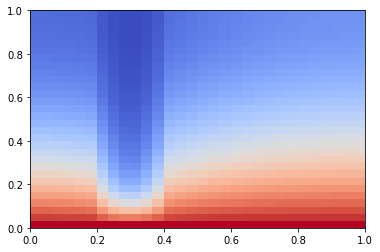

In [62]:
pcolormesh(xx,yy,theta,cmap='coolwarm')#,vmin=0, vmax=.1,aspect='auto')

In [24]:
rv1=st.expon(loc=.1,scale=0.02)
rv2=st.uniform(0,1)

Nx=100;Ny=100
deltax=1./Nx;deltay=1./Ny
deltat=.05*(deltay**2)

d=.2 # durée de l'évolution
Nt=int(d/deltat) # nombre de pas de temps


xx=np.linspace(0,1,Nx+1)
yy=np.linspace(0,1,Ny+1)
y,x=np.meshgrid(yy,xx)


cond=x<-1
Nb=10
yc=rv2.rvs(Nb)
xc=rv2.rvs(Nb)
rc=rv1.rvs(Nb)

#plot(xc,yc,'ro')

for i in range(Nb): 
    bulle=(x-xc[i])**2+(y-yc[i])**2<=rc[i]**2 
    cond=np.bitwise_or(cond,bulle)
    
fraction=x*0+1
fraction[cond]=0
np.sum(np.sum(fraction,axis=0),axis=0)/(Nx*Ny)

0.6857

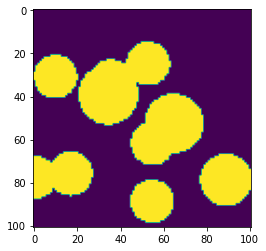

In [25]:
#a=np.sum(fraction,axis=0)
imshow(cond)
#np.sum(a,axis=0)

In [ ]:
for i in range(Nb): 
    
    inclusion=(x-x1)**2+(y-y1)**2<=r**2 
